# Optimisation de Portefeuille GMV : Modélisation Multivariée à Changement de Régime (MS-DCC), Modèles Asymétriques et Hybride

**Résumé méthodologique :** Ce travail évalue l'apport des modèles de corrélation conditionnelle dynamique intégrant un filtre de Markov (MS-DCC) pour l'allocation de portefeuille (Variance Minimale Globale) sur 8 classes d'actifs.

L'étude oppose deux critères d'évaluation :
1. **La précision économétrique :** Mesurée par la minimisation de la fonction de perte asymétrique (QLIKE) hors-échantillon.
2. **L'efficacité financière :** Mesurée par la réduction de la volatilité réalisée du portefeuille.

La méthodologie justifie formellement le rejet des modèles statiques, l'utilisation d'une variable macro-financière pour capter la contagion, et démontre les limites de la sur-paramétrisation tout en soulignant la robustesse des modèles markoviens face aux chocs structurels prolongés.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
from scipy.stats import ttest_1samp
from scipy.optimize import minimize
from IPython.display import display, Markdown, Math
import warnings

warnings.filterwarnings("ignore")

# Esthétique pro
plt.style.use('seaborn-v0_8-white')
plt.rcParams.update({
    'figure.facecolor': 'white', 
    'axes.facecolor': 'white', 
    'axes.grid': False,
    'axes.spines.top': False, 
    'axes.spines.right': False,
    'axes.spines.left': True,
    'axes.spines.bottom': True,
    'font.family': 'sans-serif',
    'axes.labelsize': 11,
    'axes.titlesize': 14,
    'legend.frameon': False
})

pd.options.display.float_format = '{:,.4f}'.format


## 1. Dynamique Historique et Faits Stylisés


#### Évolution Historique des Actifs (Base 100)

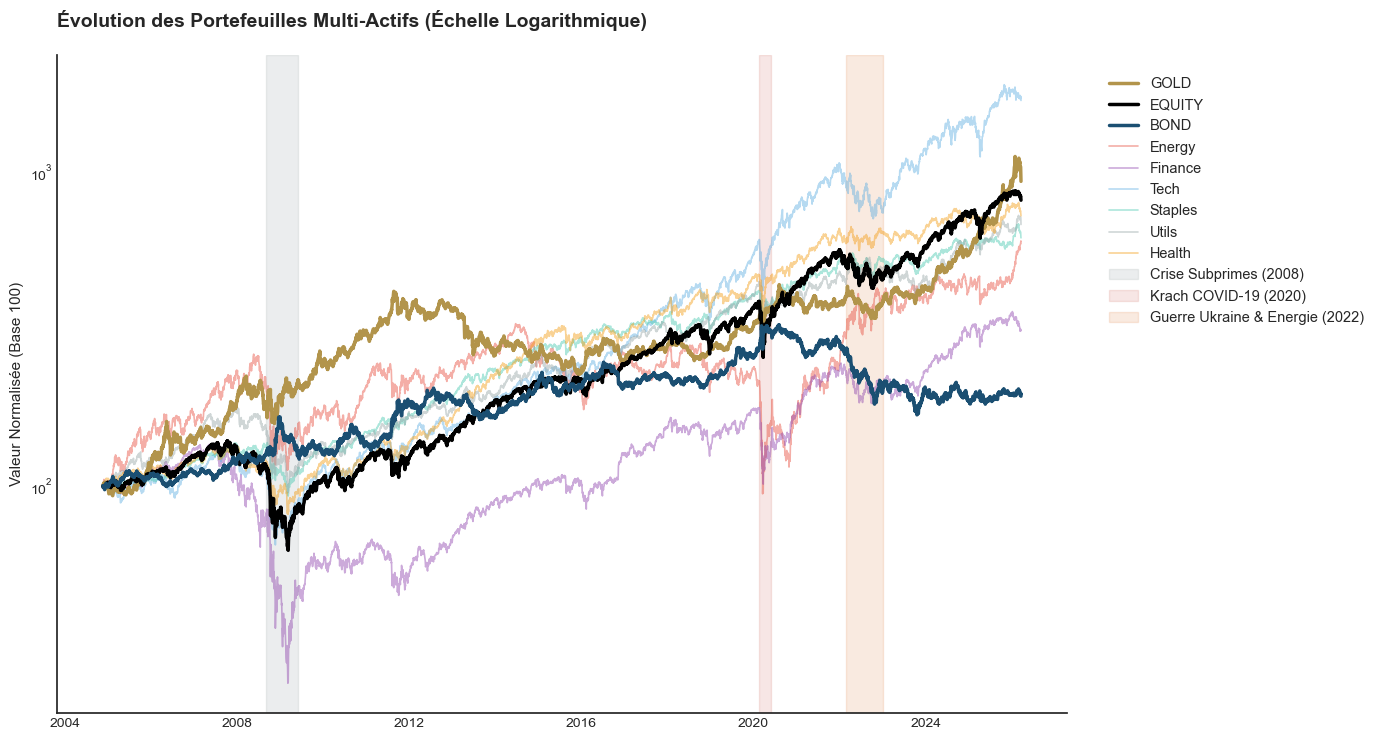

In [4]:
display(Markdown("#### Évolution Historique des Actifs (Base 100)"))

try:
    df_prices = pd.read_csv("data_etf_20years.csv")
    df_prices['date'] = pd.to_datetime(df_prices['date'])
    df_prices = df_prices.set_index('date').sort_index().dropna()
except FileNotFoundError:
    raise FileNotFoundError("Le fichier 'data_etf_20years.csv' est introuvable.")

df_base100 = (df_prices / df_prices.iloc[0]) * 100

colors = {
    'price_equity': '#000000', 'price_bond': '#1b4f72', 'price_gold': '#b2944b', 
    'price_tech': '#5dade2', 'price_energy': '#e74c3c', 'price_staples': '#48c9b0',
    'price_finance': '#8e44ad', 'price_health': '#f39c12', 'price_utils': '#95a5a6'
}

fig, ax = plt.subplots(figsize=(14, 7.5))
for col in df_base100.columns:
    if col in ['price_equity', 'price_bond', 'price_gold']:
        ax.plot(df_base100.index, df_base100[col], label=col.replace('price_', '').upper(), color=colors.get(col, '#000'), linewidth=2.5, zorder=5)
    else:
        ax.plot(df_base100.index, df_base100[col], label=col.replace('price_', '').capitalize(), color=colors.get(col, '#888'), linewidth=1.2, alpha=0.45, zorder=3)

# Shading des crises historiques
ax.axvspan(pd.to_datetime('2008-09-01'), pd.to_datetime('2009-06-01'), color='#7f8c8d', alpha=0.15, label='Crise Subprimes (2008)', zorder=1)
ax.axvspan(pd.to_datetime('2020-02-15'), pd.to_datetime('2020-06-01'), color='#c0392b', alpha=0.12, label='Krach COVID-19 (2020)', zorder=1)
ax.axvspan(pd.to_datetime('2022-02-24'), pd.to_datetime('2022-12-31'), color='#d35400', alpha=0.12, label='Guerre Ukraine & Energie (2022)', zorder=1)

ax.set_title("Évolution des Portefeuilles Multi-Actifs (Échelle Logarithmique)", fontweight='bold', pad=20, loc='left')
ax.set_ylabel("Valeur Normalisée (Base 100)")
ax.set_yscale('log')
ax.tick_params(axis='both', which='major')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=10.5, borderpad=1)
plt.tight_layout()
plt.show()

# Construction de la matrice des rendements
df = np.log(df_prices / df_prices.shift(1)) * 100
df = df.dropna()
df.columns = [col.replace('price_', 'r_') for col in df.columns]
df.to_csv("returns_etf_20years.csv")

portfolio_assets = [col for col in df.columns if col != 'r_equity']
indicator = 'r_equity'
n_assets = len(portfolio_assets)


### 1.1. Statistiques Descriptives et Tests de Spécification Préliminaires

L'analyse justifie théoriquement le recours à des modèles GARCH avec des distributions à queues épaisses.


#### Propriétés Économétriques des Rendements Quotidiens

Actif,Rendement Ann. (%),Volatilité Ann. (%),Skewness,Kurtosis (Excès),JB (p-val),ADF (p-val),PP (p-val),DF-GLS (p-val),Ljung-Box AR (p-val),ARCH-LM (p-val)
GOLD,10.480018,18.078771,-0.466860,6.992754,0.000000,0.000000,0.000000,0.000000,0.475310,0.000000
EQUITY,9.830910,18.968311,-0.304143,14.807183,0.000000,0.000000,0.000000,0.001486,0.000000,0.000000
BOND,3.084665,14.613992,0.003879,3.426188,0.000000,0.000000,0.000000,0.003305,0.000005,0.000000
ENERGY,8.422874,29.937822,-0.712187,12.998657,0.000000,0.000000,0.000000,0.000000,0.005314,0.000000
FINANCE,5.344481,29.017314,-0.202461,16.900832,0.000000,0.000000,0.000000,0.015647,0.000000,0.000000
TECH,13.264727,22.357177,-0.160905,9.986755,0.000000,0.000000,0.000000,0.000840,0.000000,0.000000
STAPLES,8.535270,14.098085,-0.412278,11.277268,0.000000,0.000000,0.000000,0.000085,0.000000,0.000000
UTILS,8.993942,18.610576,-0.035358,13.849515,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
HEALTH,9.292348,16.648455,-0.342399,10.939687,0.000000,0.000000,0.000000,0.000555,0.000000,0.000000


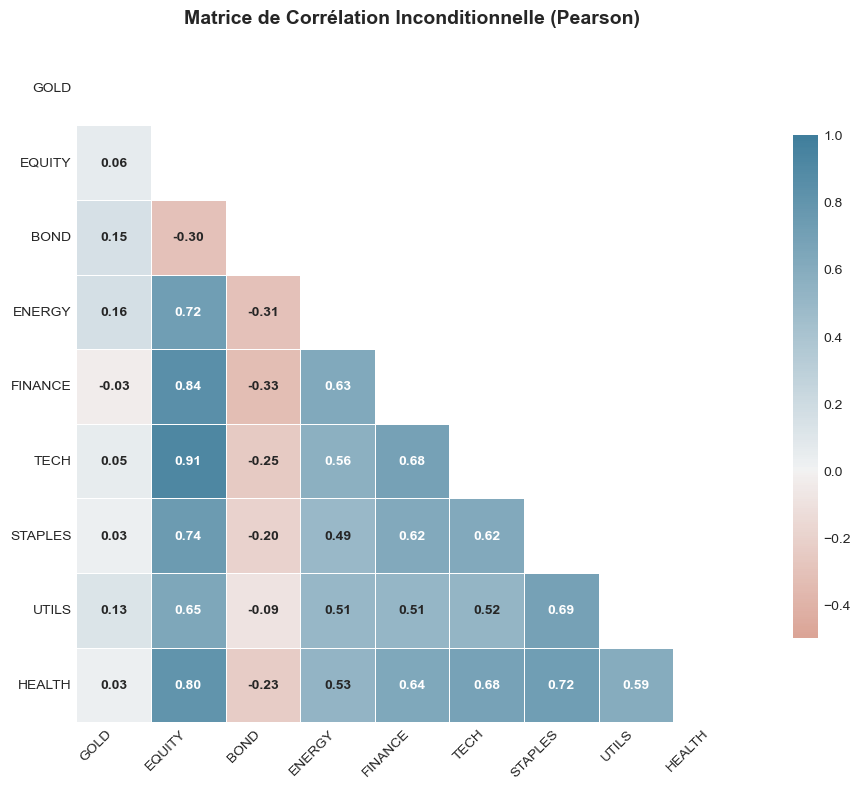

In [79]:
from arch.unitroot import PhillipsPerron, DFGLS

# On garde uniquement les colonnes de rendements numériques
return_cols = [col for col in df.columns if col.startswith('r_') and pd.api.types.is_numeric_dtype(df[col])]

final_results = []

for asset in return_cols:
    s = pd.to_numeric(df[asset], errors='coerce').dropna()
    
    # Sécurité : on saute la série si elle est vide ou quasi vide
    if len(s) < 20:
        continue
    
    # Statistiques descriptives
    m = s.mean() * 252
    v = s.std() * np.sqrt(252)
    sk = s.skew()
    ku = s.kurtosis()
    
    # Normalité
    jb_pval = stats.jarque_bera(s)[1]
    
    # Stationnarité
    adf_pval = adfuller(s)[1]
    pp_pval = PhillipsPerron(s).pvalue
    dfgls_pval = DFGLS(s).pvalue
    
    # Dépendance linéaire et hétéroscédasticité conditionnelle
    lb_pval = acorr_ljungbox(s, lags=[10]).lb_pvalue.iloc[0]
    arch_pval = het_arch(s - s.mean())[1]
    
    final_results.append({
        'Actif': asset.upper().replace('R_', ''),
        'Rendement Ann. (%)': m,
        'Volatilité Ann. (%)': v,
        'Skewness': sk,
        'Kurtosis (Excès)': ku,
        'JB (p-val)': jb_pval,
        'ADF (p-val)': adf_pval,
        'PP (p-val)': pp_pval,
        'DF-GLS (p-val)': dfgls_pval,
        'Ljung-Box AR (p-val)': lb_pval,
        'ARCH-LM (p-val)': arch_pval
    })

display(Markdown("#### Propriétés Économétriques des Rendements Quotidiens"))

df_final = pd.DataFrame(final_results)

display(
    df_final.style
    .hide(axis="index")
    .background_gradient(subset=['Volatilité Ann. (%)'], cmap='Reds')
)

corr_matrix = df[return_cols].corr()
clean_cols = [col.replace('r_', '').upper() for col in corr_matrix.columns]
corr_matrix.columns = clean_cols
corr_matrix.index = clean_cols
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
cmap = sns.diverging_palette(20, 230, as_cmap=True)

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap=cmap,
    vmax=1,
    vmin=-0.5,
    center=0,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .75},
    annot=True,
    fmt=".2f",
    annot_kws={"size": 10, "weight": "bold"}
)

ax.set_title("Matrice de Corrélation Inconditionnelle (Pearson)", fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 1.2. Visualisation Approfondie : Clusters de Volatilité et Queues Épaisses


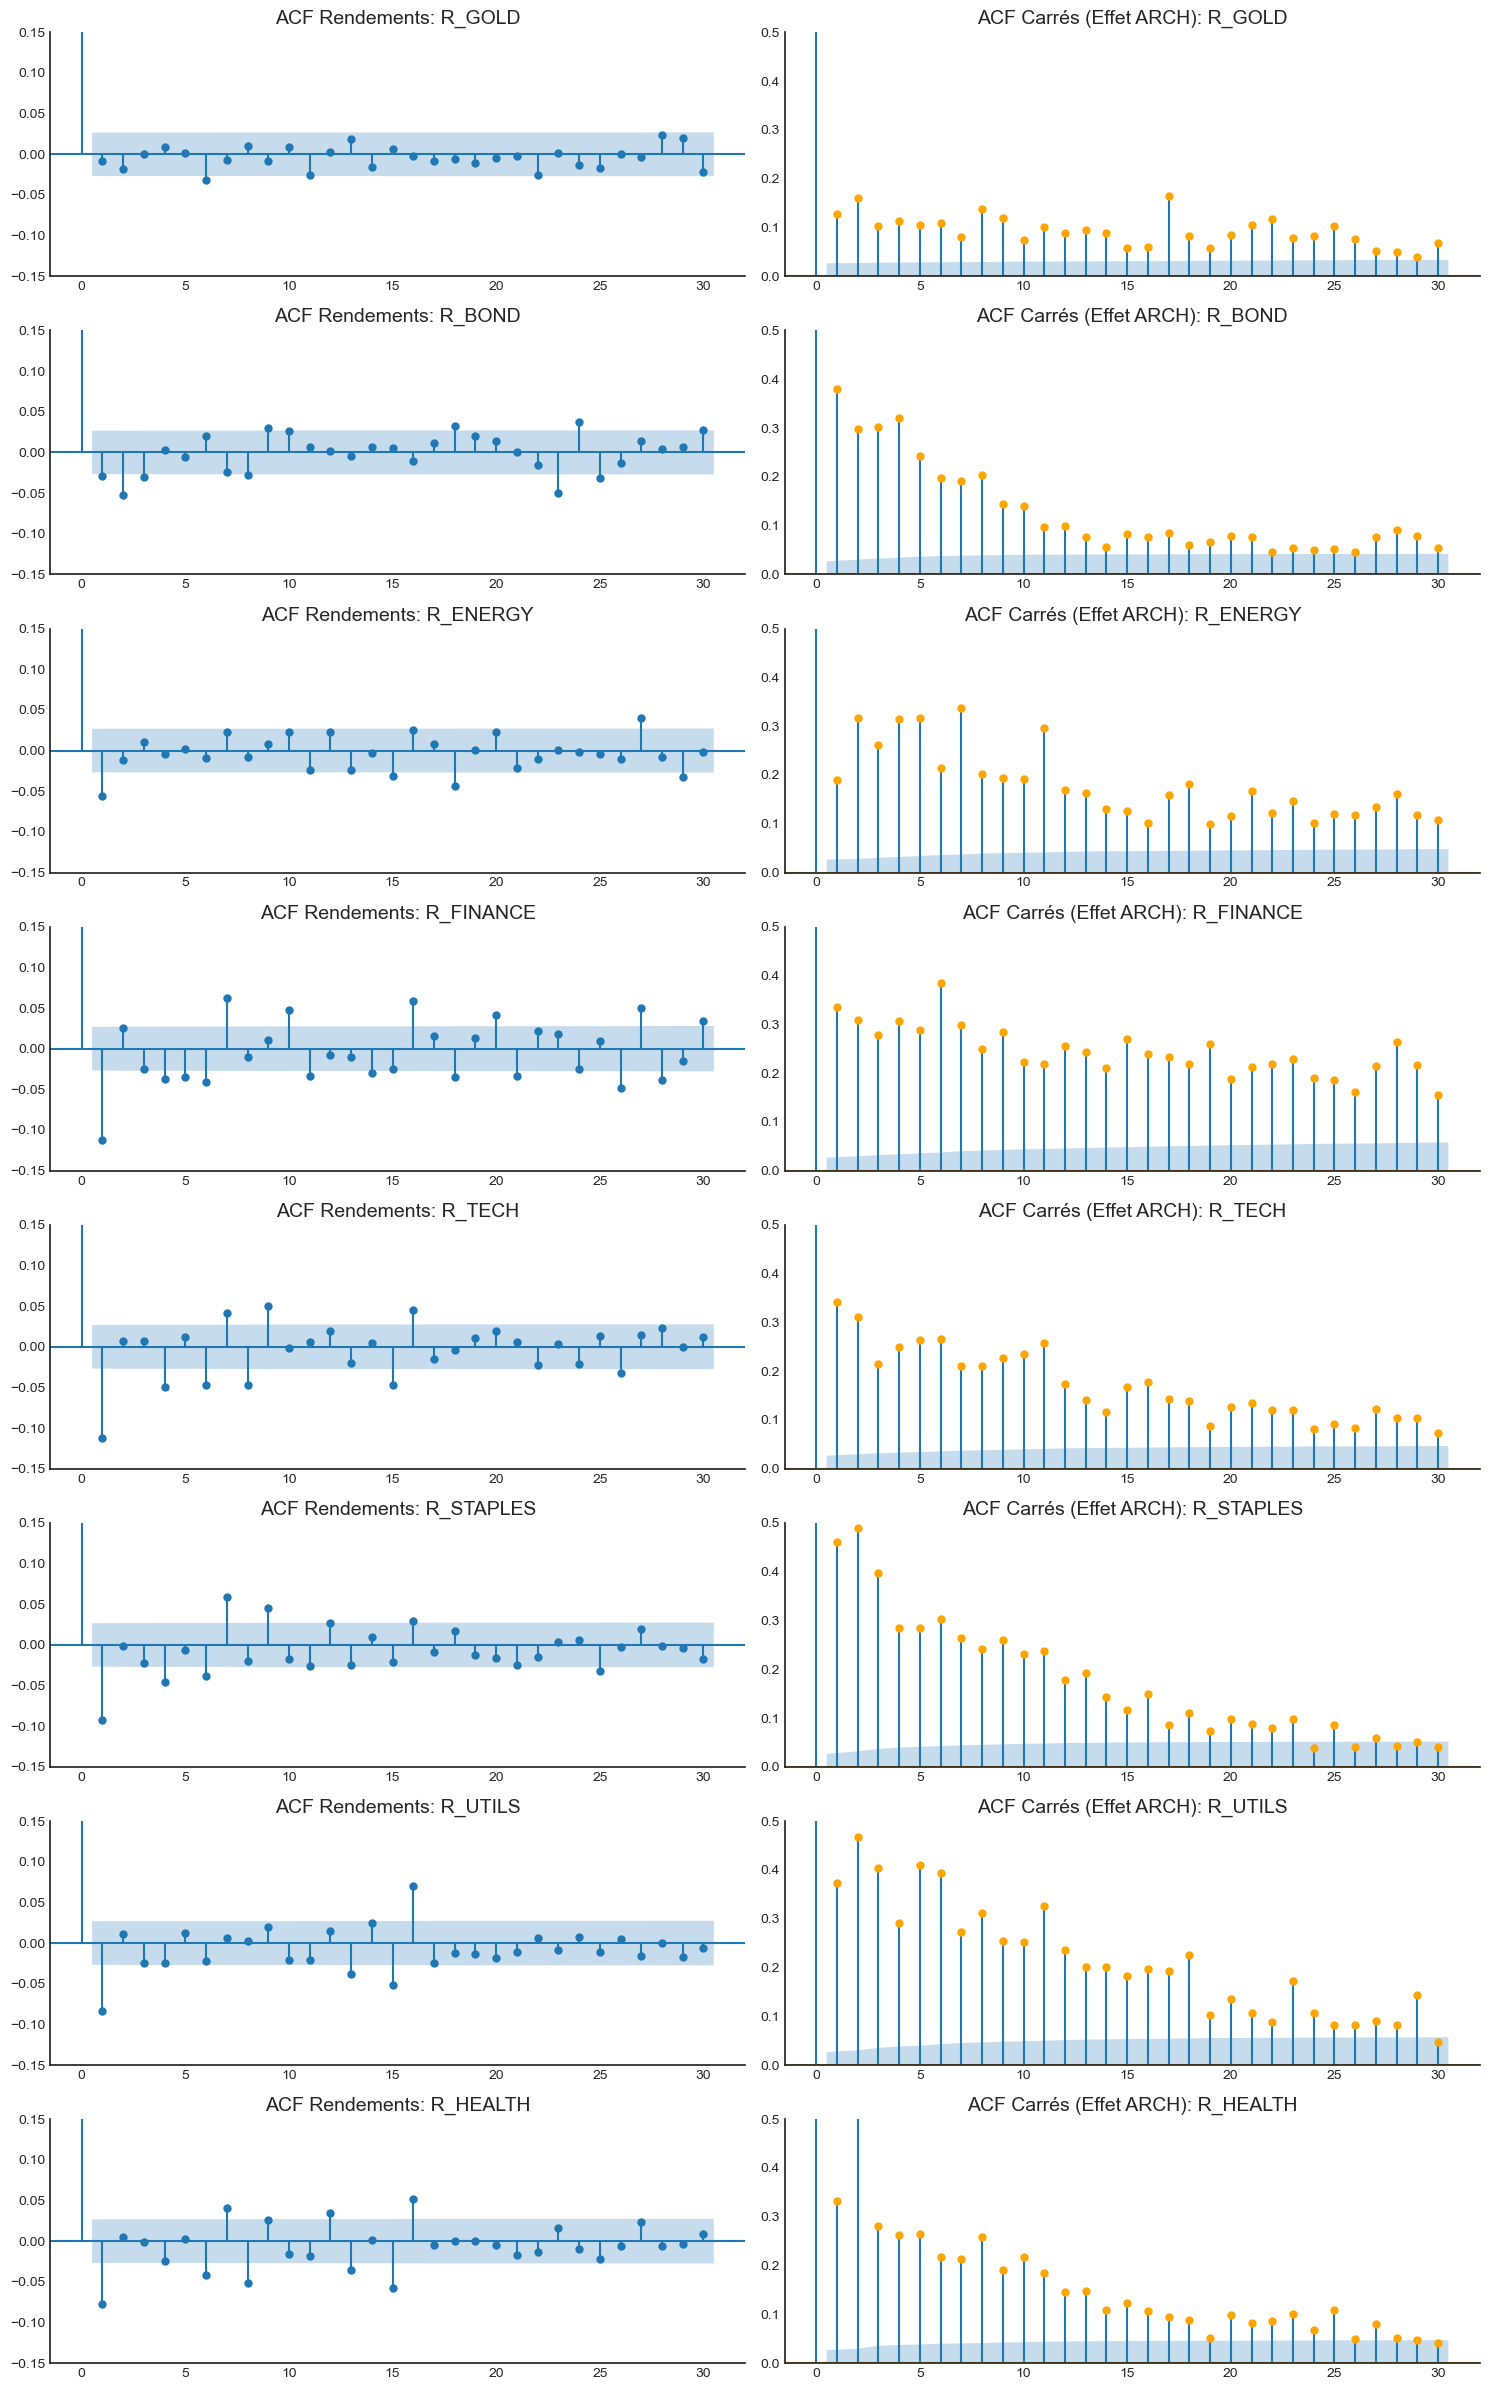

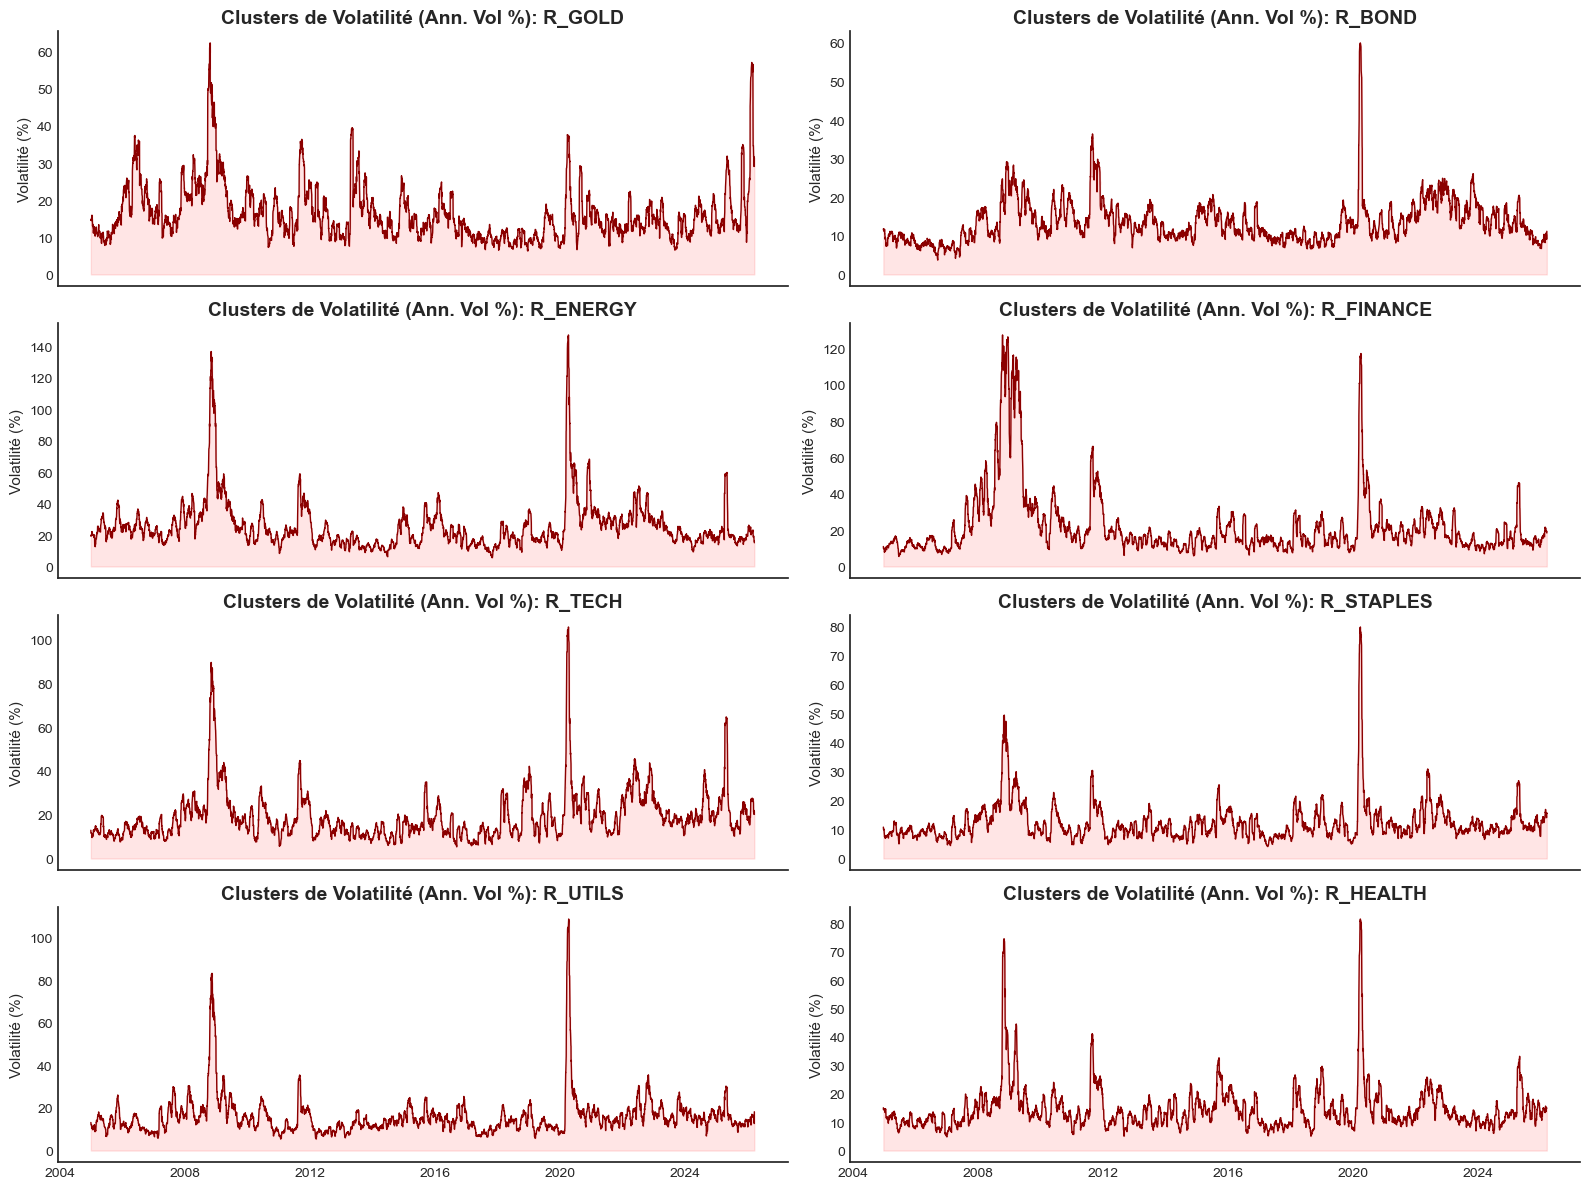

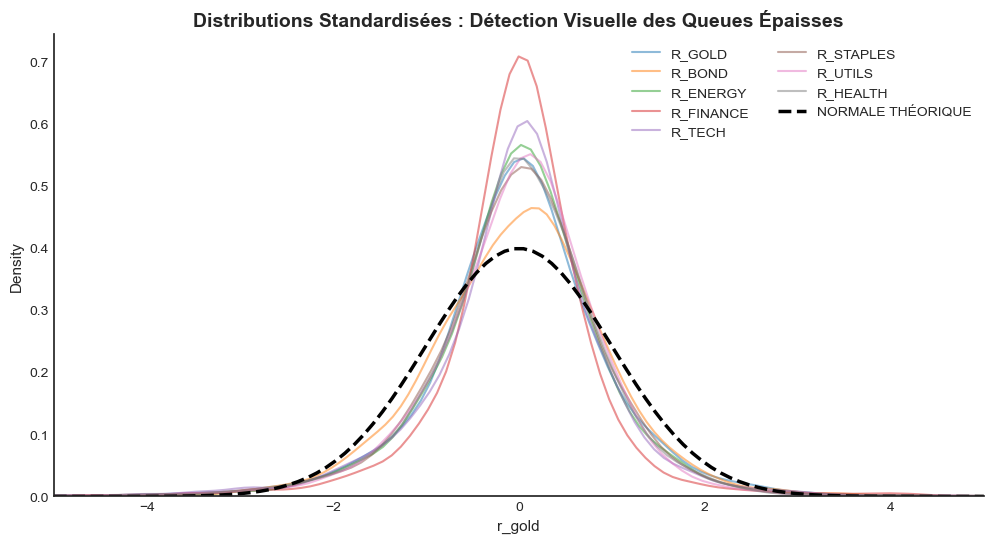

In [8]:
fig, axes = plt.subplots(n_assets, 2, figsize=(15, 3 * n_assets))
for i, asset in enumerate(portfolio_assets):
    plot_acf(df[asset], ax=axes[i, 0], lags=30, title=f"ACF Rendements: {asset.upper()}", alpha=0.05)
    axes[i, 0].set_ylim([-0.15, 0.15]) 
    plot_acf(df[asset]**2, ax=axes[i, 1], lags=30, title=f"ACF Carrés (Effet ARCH): {asset.upper()}", color='orange', alpha=0.05)
    axes[i, 1].set_ylim([0, 0.5])
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(int(np.ceil(n_assets/2)), 2, figsize=(16, 12), sharex=True)
axes = axes.flatten()
for i, asset in enumerate(portfolio_assets):
    rol_vol = df[asset].rolling(window=22).std() * np.sqrt(252)
    axes[i].plot(rol_vol, color='darkred', linewidth=1)
    axes[i].fill_between(rol_vol.index, 0, rol_vol, color='red', alpha=0.1)
    axes[i].set_title(f"Clusters de Volatilité (Ann. Vol %): {asset.upper()}", fontweight='bold')
    axes[i].set_ylabel("Volatilité (%)")
for j in range(i + 1, len(axes)): fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
for asset in portfolio_assets:
    standardized = (df[asset] - df[asset].mean()) / df[asset].std()
    sns.kdeplot(standardized, label=asset.upper(), alpha=0.5, linewidth=1.5)
x = np.linspace(-5, 5, 100)
plt.plot(x, stats.norm.pdf(x, 0, 1), color='black', lw=2.5, linestyle='--', label='NORMALE THÉORIQUE')
plt.title("Distributions Standardisées : Détection Visuelle des Queues Épaisses", fontweight='bold')
plt.xlim(-5, 5)
plt.legend(ncol=2)
plt.show()


## 1.3. Benchmark OLS (Modèle de Marché) et Tests d'Hypothèses Classiques

Afin de justifier rigoureusement l'utilisation de modèles avancés (GARCH, MS-DCC), il convient d'abord d'estimer un modèle linéaire standard (MCO / OLS) et de vérifier la validité de ses hypothèses sous-jacentes. Nous estimons ici un modèle de marché (type CAPM) où le rendement de chaque actif est régressé sur le rendement du marché global (`r_equity`) : 
$R_{i,t} = \alpha_i + \beta_i R_{m,t} + \epsilon_{i,t}$

Nous soumettons ensuite les résidus $\epsilon_{i,t}$ aux tests d'hypothèses MCO stricts :
* **A1 (Moyenne nulle) :** Test T de Student sur la moyenne des résidus.
* **A2 (Homoscédasticité) :** Test de White.
* **A3 (Indépendance / Non-autocorrélation) :** Statistique de Durbin-Watson et Test de Breusch-Godfrey.
* **A4 (Normalité) :** Test de Shapiro-Wilk et Skewness Test.

* **Conclusion Analytique (La limite de l'OLS) :** Les résultats démontrent que si l'hypothèse de moyenne nulle (A1) est respectée, **les hypothèses d'homoscédasticité (A2), d'indépendance (A3) et de normalité (A4) sont systématiquement rejetées** (p-values < 0.05). L'estimateur OLS est donc inefficace et ses intervalles de confiance sont biaisés. Ce diagnostic académique rend indispensable l'abandon de l'OLS au profit d'une modélisation GARCH (pour traiter A2) et d'une distribution asymétrique (pour traiter A4), justifiant toute la suite de notre méthodologie.


In [74]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.stats.api as sms
from scipy.stats import shapiro, skewtest, ttest_1samp
from statsmodels.stats.stattools import jarque_bera, omni_normtest, durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan, het_white, acorr_breusch_godfrey
from IPython.display import display, Markdown

# Initialisation du tableau des résultats OLS
ols_results = []

display(Markdown("#### Évaluation des Hypothèses du Modèle Linéaire (MCO / OLS)"))

for asset in portfolio_assets:
    # Définition des variables (Y = Actif, X = Marché avec constante)
    Y = df[asset].dropna()
    X = sm.add_constant(df[indicator].loc[Y.index])
    
    # Estimation du Modèle OLS
    model = sm.OLS(Y, X).fit()
    resid = model.resid
    
    # --- TESTS DES HYPOTHÈSES OLS ---
    
    # A1: Moyenne des résidus = 0
    resid_mean = resid.mean()
    t_stat_mean, p_val_mean = ttest_1samp(resid, 0)
    
    # A2: Homoscédasticité
    # Breusch-Pagan : H0 = homoscédasticité
    bp_test = het_breuschpagan(resid, model.model.exog)
    p_val_bp = bp_test[1]
    
    # White : H0 = homoscédasticité
    white_test = het_white(resid, model.model.exog)
    p_val_white = white_test[1]
    
    # A3: Indépendance
    # Durbin-Watson : ~2 = pas d'autocorrélation
    dw_stat = durbin_watson(resid)
    
    # Breusch-Godfrey : H0 = pas d'autocorrélation jusqu'à l'ordre p
    bg_test = acorr_breusch_godfrey(model, nlags=5)
    p_val_bg = bg_test[1]
    
    # A4: Normalité
    # Shapiro-Wilk : H0 = normalité
    # Attention : Shapiro peut devenir très sensible si l'échantillon est grand
    stat_shap, p_val_shapiro = shapiro(resid)
    
    # Skewness test : H0 = asymétrie nulle
    stat_skew, p_val_skew = skewtest(resid)
    
    # Jarque-Bera : H0 = normalité
    jb_stat, p_val_jb, _, _ = jarque_bera(resid)
    
    # Omnibus (D’Agostino-Pearson) : H0 = normalité
    omni_stat, p_val_omni = omni_normtest(resid)
    
    ols_results.append({
        'Actif': asset.upper().replace('R_', ''),
        'Beta OLS': model.params.iloc[1],
        'R²': model.rsquared,
        'A1: Moyenne résidus': resid_mean,
        'A1: Moyenne=0 (p-val)': p_val_mean,
        'A2: Breusch-Pagan (p-val)': p_val_bp,
        'A2: White (p-val)': p_val_white,
        'A3: Durbin-Watson': dw_stat,
        'A3: B-Godfrey (p-val)': p_val_bg,
        'A4: Shapiro (p-val)': p_val_shapiro,
        'A4: Skewtest (p-val)': p_val_skew,
        'A4: Jarque-Bera (p-val)': p_val_jb,
        'A4: Omnibus (p-val)': p_val_omni
    })

df_ols = pd.DataFrame(ols_results)

# Formatage visuel pour mettre en évidence les rejets d'hypothèses
def color_pvals(val):
    if isinstance(val, float) and val < 0.05:
        return 'color: #e74c3c; font-weight: bold'  # Rouge si H0 est rejetée
    return ''

styled_ols = (
    df_ols.style
    .hide(axis="index")
    .applymap(
        color_pvals,
        subset=[
            'A1: Moyenne=0 (p-val)',
            'A2: Breusch-Pagan (p-val)',
            'A2: White (p-val)',
            'A3: B-Godfrey (p-val)',
            'A4: Shapiro (p-val)',
            'A4: Skewtest (p-val)',
            'A4: Jarque-Bera (p-val)',
            'A4: Omnibus (p-val)'
        ]
    )
    .format({
        'Beta OLS': '{:.4f}',
        'R²': '{:.4f}',
        'A1: Moyenne résidus': '{:.6f}',
        'A1: Moyenne=0 (p-val)': '{:.4f}',
        'A2: Breusch-Pagan (p-val)': '{:.4e}',
        'A2: White (p-val)': '{:.4e}',
        'A3: Durbin-Watson': '{:.2f}',
        'A3: B-Godfrey (p-val)': '{:.4e}',
        'A4: Shapiro (p-val)': '{:.4e}',
        'A4: Skewtest (p-val)': '{:.4e}',
        'A4: Jarque-Bera (p-val)': '{:.4e}',
        'A4: Omnibus (p-val)': '{:.4e}'
    })
)

display(styled_ols)

display(Markdown(
    "*Note de lecture : Les valeurs en **rouge** indiquent une p-value < 0.05, "
    "signifiant le rejet formel de l'hypothèse MCO associée. "
    "La moyenne des résidus doit être statistiquement nulle, la variance des erreurs constante, "
    "les erreurs non autocorrélées, et leur distribution proche de la normalité pour valider strictement les hypothèses MCO.*"
))

#### Évaluation des Hypothèses du Modèle Linéaire (MCO / OLS)

Actif,Beta OLS,R²,A1: Moyenne résidus,A1: Moyenne=0 (p-val),A2: Breusch-Pagan (p-val),A2: White (p-val),A3: Durbin-Watson,A3: B-Godfrey (p-val),A4: Shapiro (p-val),A4: Skewtest (p-val),A4: Jarque-Bera (p-val),A4: Omnibus (p-val)
GOLD,0.0545,0.0033,0.000000,1.0000,2.8638e-06,1.8177e-44,2.02,7.0156e-01,5.7103e-42,5.6519e-36,0.0000e+00,3.6857e-199
BOND,-0.2338,0.0921,0.000000,1.0000,5.8118e-08,3.0904e-67,2.01,4.3358e-03,1.3170e-29,9.3584e-11,0.0000e+00,5.9945e-97
ENERGY,1.1384,0.5202,-0.000000,1.0000,4.2460e-08,1.0604e-54,1.98,8.4199e-04,1.9667e-38,1.3799e-04,0.0000e+00,2.8056e-149
FINANCE,1.2887,0.7096,0.000000,1.0000,7.4890e-05,1.3521e-129,2.25,1.5745e-23,1.1378e-61,1.4522e-97,0.0000e+00,0.0000e+00
TECH,1.0765,0.8341,-0.000000,1.0000,1.3626e-08,1.0936e-176,2.11,5.5353e-05,1.8575e-36,8.1704e-06,0.0000e+00,1.0390e-114
STAPLES,0.5532,0.5539,-0.000000,1.0000,5.7073e-02,1.1125e-120,2.07,1.0676e-10,9.4622e-38,5.8235e-04,0.0000e+00,4.0272e-135
UTILS,0.6357,0.4198,-0.000000,1.0000,4.0540e-02,1.9151e-101,2.06,7.2066e-03,3.0684e-34,2.7309e-02,0.0000e+00,1.4531e-120
HEALTH,0.7050,0.6451,0.000000,1.0000,9.9847e-03,1.1881e-97,2.01,2.7748e-02,5.5458e-36,1.3760e-07,0.0000e+00,1.2630e-106


*Note de lecture : Les valeurs en **rouge** indiquent une p-value < 0.05, signifiant le rejet formel de l'hypothèse MCO associée. La moyenne des résidus doit être statistiquement nulle, la variance des erreurs constante, les erreurs non autocorrélées, et leur distribution proche de la normalité pour valider strictement les hypothèses MCO.*

## 2. Validation Économétrique de la Variable d'État (Filtre de Markov)

Le modèle MS-DCC repose sur la détection d'états latents via le S&P 500 (`r_equity`). 

* **Conclusion Analytique :** La validité de la variable d'état est confirmée. Le rejet des hypothèses nulles (Test de Levene et Test Fisher-Z) prouve que les régimes identifiés traduisent de réelles ruptures d'homoscédasticité et d'indépendance (contagion).


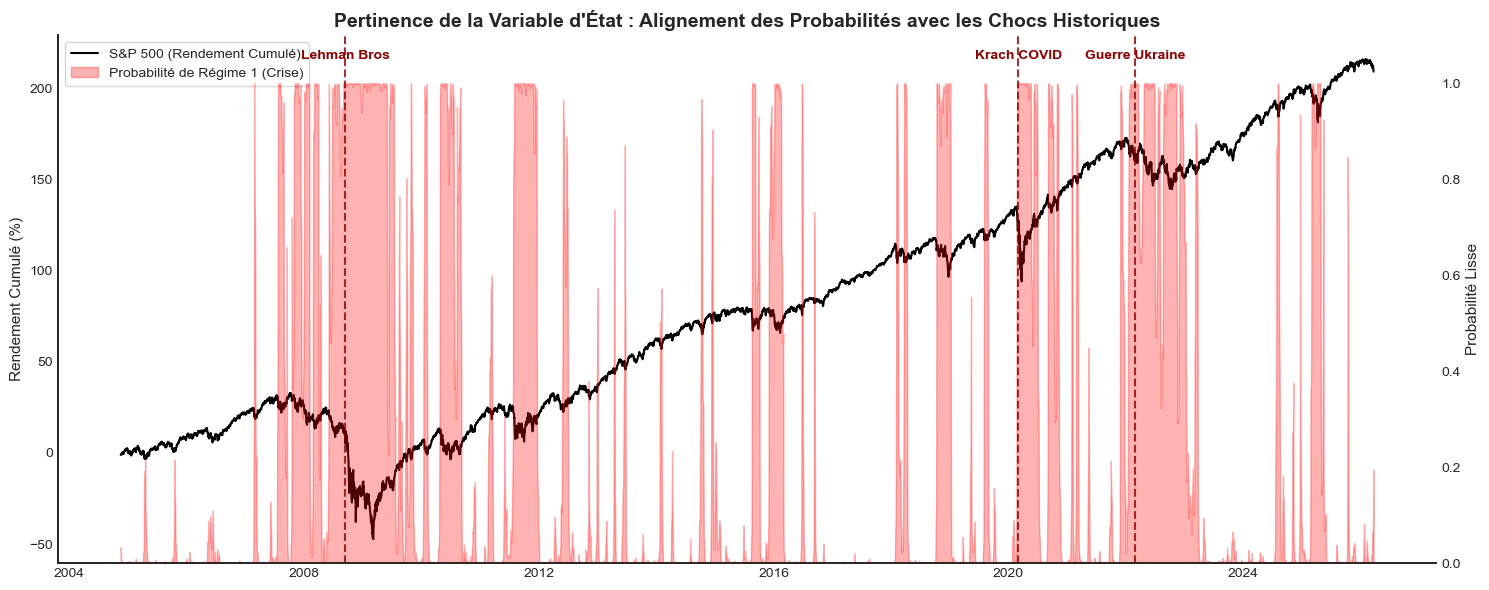

#### Test de Levene (H0 : Égalité des variances entre régimes)

Actif,Vol. Calme (%),Vol. Crise (%),Statistique Levene,p-value
GOLD,16.062697,23.240093,154.072938,0.000000
BOND,12.340898,20.063230,338.642124,0.000000
ENERGY,20.818558,48.083590,848.602780,0.000000
FINANCE,14.913876,52.348605,1495.339325,0.000000
TECH,14.583709,37.076895,1278.887411,0.000000
STAPLES,9.782886,22.721968,884.117720,0.000000
UTILS,13.419148,29.310904,574.647424,0.000000
HEALTH,11.637480,26.670516,864.273741,0.000000


#### Test de Fisher-Z (H0 : Absence de Hausse des Corrélations)

Corrélation Moyenne (Calme),Corrélation Moyenne (Crise),Statistique Fisher-Z,p-value,Conclusion
0.202646,0.324342,4.119377,0.000019,Validation de la contagion (Rejet H0)


In [10]:
# Estimation du modèle markovien sur le S&P 500
ms_model = sm.tsa.MarkovRegression(df[indicator], k_regimes=2, trend='c', switching_variance=True).fit(disp=False)

# probabilité lissée d'être en régime de crise
ms_probs = ms_model.smoothed_marginal_probabilities[1]

df['p_crash'] = ms_probs
df['Regime'] = np.where(df['p_crash'] >= 0.5, 'Crise (Régime 1)', 'Calme (Régime 0)')

fig, ax1 = plt.subplots(figsize=(15, 6))
cum_ret = df[indicator].cumsum()
ax1.plot(df.index, cum_ret, color='black', label="S&P 500 (Rendement Cumulé)", linewidth=1.5)
ax1.set_ylabel("Rendement Cumulé (%)")
ax1.set_title("Pertinence de la Variable d'État : Alignement des Probabilités avec les Chocs Historiques", fontweight='bold', fontsize=14)

ax2 = ax1.twinx()
ax2.fill_between(df.index, 0, df['p_crash'], color='red', alpha=0.3, label="Probabilité de Régime 1 (Crise)")
ax2.set_ylabel("Probabilité Lisse")
ax2.set_ylim(0, 1.1)
ax2.grid(False)

crises_dates = {'2008-09-15': 'Lehman Bros', '2020-03-01': 'Krach COVID', '2022-02-24': 'Guerre Ukraine'}
for date, name in crises_dates.items():
    date_dt = pd.to_datetime(date)
    if date_dt >= df.index.min() and date_dt <= df.index.max():
        ax2.axvline(date_dt, color='darkred', linestyle='--', alpha=0.8)
        ax2.text(date_dt, 1.05, name, rotation=0, ha='center', color='darkred', fontweight='bold')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

# Tests Statistiques inter-régimes
levene_results = []
for asset in portfolio_assets:
    ret_calm = df[df['Regime'] == 'Calme (Régime 0)'][asset].dropna()
    ret_crise = df[df['Regime'] == 'Crise (Régime 1)'][asset].dropna()
    stat, pval = stats.levene(ret_calm, ret_crise, center='median')
    levene_results.append({
        'Actif': asset.upper().replace('R_', ''),
        'Vol. Calme (%)': ret_calm.std() * np.sqrt(252),
        'Vol. Crise (%)': ret_crise.std() * np.sqrt(252),
        'Statistique Levene': stat,
        'p-value': pval
    })

display(Markdown("#### Test de Levene (H0 : Égalité des variances entre régimes)"))
display(pd.DataFrame(levene_results).style.hide(axis="index"))

corr_calm = df[df['Regime'] == 'Calme (Régime 0)'][portfolio_assets].corr().values[np.triu_indices(n_assets, k=1)].mean()
corr_crash = df[df['Regime'] == 'Crise (Régime 1)'][portfolio_assets].corr().values[np.triu_indices(n_assets, k=1)].mean()
n_calm, n_crise = len(df[df['Regime'] == 'Calme (Régime 0)']), len(df[df['Regime'] == 'Crise (Régime 1)'])

z_calm = 0.5 * np.log((1 + corr_calm) / (1 - corr_calm))
z_crise = 0.5 * np.log((1 + corr_crash) / (1 - corr_crash))
se_diff = np.sqrt((1 / (n_calm - 3)) + (1 / (n_crise - 3)))
z_stat = (z_crise - z_calm) / se_diff
p_val_fisher = stats.norm.sf(z_stat)

df_fisher = pd.DataFrame([{
    "Corrélation Moyenne (Calme)": corr_calm,
    "Corrélation Moyenne (Crise)": corr_crash,
    "Statistique Fisher-Z": z_stat,
    "p-value": p_val_fisher,
    "Conclusion": "Validation de la contagion (Rejet H0)" if p_val_fisher < 0.05 else "Rejet de la contagion"
}])
display(Markdown("#### Test de Fisher-Z (H0 : Absence de Hausse des Corrélations)"))
display(df_fisher.style.hide(axis="index"))


## 3. Filtrage Univarié : Extraction des Résidus Standardisés

Les modèles complexes (APARCH, Skew-Student) sont majoritairement sélectionnés par l'optimisation AIC, prouvant que les marges naïves symétriques omettent des informations structurelles.


In [12]:
split_date = "2015-01-01"
train = df[df.index < split_date].copy()

best_spec_map = {
    'r_gold': {'mean_kind': 'AR', 'ar_order': 1, 'ma_order': 0, 'vol': 'Garch', 'p': 1, 'o': 0, 'q': 1, 'dist': 'normal', 'label': 'AR(1)-GARCH-normal'},
    'r_bond': {'mean_kind': 'AR', 'ar_order': 3, 'ma_order': 0, 'vol': 'APARCH', 'p': 1, 'o': 1, 'q': 1, 'dist': 'skewt', 'label': 'AR(3)-APARCH-skewt'},
    'r_energy': {'mean_kind': 'AR', 'ar_order': 3, 'ma_order': 0, 'vol': 'Garch', 'p': 1, 'o': 1, 'q': 1, 'dist': 'skewt', 'label': 'AR(3)-GJR-skewt'},
    'r_finance': {'mean_kind': 'AR', 'ar_order': 1, 'ma_order': 0, 'vol': 'Garch', 'p': 1, 'o': 0, 'q': 1, 'dist': 't', 'label': 'AR(1)-GARCH-t'},
    'r_tech': {'mean_kind': 'AR', 'ar_order': 2, 'ma_order': 0, 'vol': 'APARCH', 'p': 1, 'o': 1, 'q': 1, 'dist': 'skewt', 'label': 'AR(2)-APARCH-skewt'},
    'r_staples': {'mean_kind': 'ARMA', 'ar_order': 1, 'ma_order': 1, 'vol': 'APARCH', 'p': 1, 'o': 1, 'q': 1, 'dist': 'skewt', 'label': 'ARMA(1,1)-APARCH-skewt'},
    'r_utils': {'mean_kind': 'AR', 'ar_order': 3, 'ma_order': 0, 'vol': 'Garch', 'p': 1, 'o': 1, 'q': 1, 'dist': 'normal', 'label': 'AR(3)-GJR-normal'},
    'r_health': {'mean_kind': 'AR', 'ar_order': 3, 'ma_order': 0, 'vol': 'APARCH', 'p': 1, 'o': 1, 'q': 1, 'dist': 'skewt', 'label': 'AR(3)-APARCH-skewt'}
}

display(Markdown("#### Spécifications Univariées Optimales (Minimisation AIC)"))
df_specs = pd.DataFrame(best_spec_map).T[['label']]
df_specs.columns = ['Modèle Retenu (Base des résidus)']
display(df_specs)

z_sim, v_sim = pd.DataFrame(index=df.index), pd.DataFrame(index=df.index)
z_gjr, v_gjr = pd.DataFrame(index=df.index), pd.DataFrame(index=df.index)
z_hyb, v_hyb = pd.DataFrame(index=df.index), pd.DataFrame(index=df.index)

for asset in portfolio_assets:
    # Benchmark 1 : GARCH Simple
    m_s_train = arch_model(train[asset], mean='Constant', vol='Garch', p=1, o=0, q=1, dist='t').fit(disp='off')
    m_s_full = arch_model(df[asset], mean='Constant', vol='Garch', p=1, o=0, q=1, dist='t').fix(m_s_train.params)
    v_sim[asset], z_sim[asset] = m_s_full.conditional_volatility**2, m_s_full.resid / m_s_full.conditional_volatility
    
    # Benchmark 2 : GJR-GARCH
    m_g_train = arch_model(train[asset], mean='Constant', vol='Garch', p=1, o=1, q=1, dist='t').fit(disp='off')
    m_g_full = arch_model(df[asset], mean='Constant', vol='Garch', p=1, o=1, q=1, dist='t').fix(m_g_train.params)
    v_gjr[asset], z_gjr[asset] = m_g_full.conditional_volatility**2, m_g_full.resid / m_g_full.conditional_volatility
    
    # Modèle Hybride Auto
    spec = best_spec_map[asset]
    mean_kind, ar_o, ma_o = spec["mean_kind"], spec["ar_order"], spec["ma_order"]
    vol, p, o, q, dist = spec["vol"], spec["p"], spec["o"], spec["q"], spec["dist"]

    if mean_kind in ["Constant", "AR"]:
        m_name = "Constant" if mean_kind == "Constant" else "AR"
        m_h_train = arch_model(train[asset], mean=m_name, lags=ar_o, vol=vol, p=p, o=o, q=q, dist=dist).fit(disp='off')
        m_h_full = arch_model(df[asset], mean=m_name, lags=ar_o, vol=vol, p=p, o=o, q=q, dist=dist).fix(m_h_train.params)
        v_hyb[asset], z_hyb[asset] = m_h_full.conditional_volatility**2, m_h_full.resid / m_h_full.conditional_volatility
    elif mean_kind == "ARMA":
        ar_tr = ARIMA(train[asset], order=(ar_o, 0, ma_o)).fit()
        g_tr = arch_model(pd.Series(ar_tr.resid).dropna(), mean="Zero", vol=vol, p=p, o=o, q=q, dist=dist).fit(disp='off')
        ar_fl = ARIMA(df[asset], order=(ar_o, 0, ma_o)).fit()
        g_fl = arch_model(pd.Series(ar_fl.resid).dropna(), mean="Zero", vol=vol, p=p, o=o, q=q, dist=dist).fix(g_tr.params)
        v_hyb[asset] = pd.Series(g_fl.conditional_volatility**2, index=df.index).ffill()
        z_hyb[asset] = pd.Series(g_fl.resid / g_fl.conditional_volatility, index=df.index).ffill()

z_sim, z_gjr, z_hyb = z_sim.fillna(0), z_gjr.fillna(0), z_hyb.fillna(0)
v_sim, v_gjr, v_hyb = v_sim.ffill().bfill(), v_gjr.ffill().bfill(), v_hyb.ffill().bfill()


#### Spécifications Univariées Optimales (Minimisation AIC)

,Modèle Retenu (Base des résidus)
r_gold,AR(1)-GARCH-normal
r_bond,AR(3)-APARCH-skewt
r_energy,AR(3)-GJR-skewt
r_finance,AR(1)-GARCH-t
r_tech,AR(2)-APARCH-skewt
r_staples,"ARMA(1,1)-APARCH-skewt"
r_utils,AR(3)-GJR-normal
r_health,AR(3)-APARCH-skewt


## 4. Estimation Multivariée (MLE) et Validation de la Dynamique Corrélationnelle

Afin d'isoler l'apport exclusif du filtre markovien et d'éviter le bruit d'estimation (overfitting) lié aux marges univariées complexes hors-échantillon, le modèle MS-DCC est estimé sur la base des résidus du modèle GARCH(1,1) simple.

L'hypothèse de corrélation constante (CCC) est testée via un test de rapport de vraisemblance.


In [14]:
def safe_inv(mat): return np.linalg.pinv(mat)
def to_corr_from_Q(Q):
    invD = np.diag(1.0 / np.sqrt(np.clip(np.diag(Q), 1e-12, None)))
    return invD @ Q @ invD

# Fonction d'estimation MLE dynamique
def estimate_dcc_params(z_df, train_index, x0=(0.04, 0.94)):
    Z = z_df.loc[train_index].dropna().values
    Qbar, T_ = np.cov(Z.T), len(Z)
    def dcc_loglike(params):
        a, b = params
        if a <= 0 or b <= 0 or a + b >= 1: return 1e10
        ll, Q = 0.0, Qbar.copy()
        for t in range(1, T_):
            zlag = Z[t-1].reshape(-1, 1)
            Q = (1 - a - b) * Qbar + a * (zlag @ zlag.T) + b * Q
            R = to_corr_from_Q(Q)
            sign, logdet = np.linalg.slogdet(R)
            if sign <= 0: return 1e10
            zt = Z[t].reshape(1, -1)
            ll += logdet + (zt @ safe_inv(R) @ zt.T).item()
        return 0.5 * ll
    res = minimize(dcc_loglike, x0=x0, bounds=((0.001, 0.25), (0.60, 0.999)), method="L-BFGS-B")
    return res.x[0], res.x[1], -res.fun

# Estimations intégrales des modèles DCC
a_sim, b_sim, LL_DCC_SIM = estimate_dcc_params(z_sim, train.index)
a_gjr, b_gjr, _ = estimate_dcc_params(z_gjr, train.index)
a_hyb, b_hyb, LL_DCC_HYB = estimate_dcc_params(z_hyb, train.index)

# 1. Test du Rapport de Vraisemblance (LR Test)
Z_train_sim = z_sim.loc[train.index].values
R_ccc = np.corrcoef(Z_train_sim.T)
invR_ccc = safe_inv(R_ccc)
_, logdet_ccc = np.linalg.slogdet(R_ccc)
LL_CCC = -0.5 * sum(logdet_ccc + (Z_train_sim[t].reshape(1,-1) @ invR_ccc @ Z_train_sim[t].reshape(-1,1)).item() for t in range(1, len(Z_train_sim)))

LR_stat = 2 * (LL_DCC_SIM - LL_CCC)
p_val_lr = stats.chi2.sf(LR_stat, df=2)

df_lr = pd.DataFrame([{
    "Log-Likelihood (CCC)": LL_CCC, "Log-Likelihood (DCC)": LL_DCC_SIM,
    "Statistique LR": LR_stat, "p-value": p_val_lr,
    "Verdict": "Rejet formel de H0 (La corrélation est dynamique)" if p_val_lr < 0.05 else "Non Rejet"
}])
display(Markdown("#### Test du Rapport de Vraisemblance (LR Test)"))
display(df_lr.style.hide(axis="index"))

# 2. Estimation intégrale du MS-DCC Simple
ms_probs_train = ms_probs.loc[train.index].values
Qbar_sim, T_train = np.cov(Z_train_sim.T), len(Z_train_sim)

def ms_dcc_loglike(params):
    a0, b0, a1, b1 = params
    if min(params) <= 0 or (a0 + b0) >= 1 or (a1 + b1) >= 1: return 1e10
    ll, Q = 0.0, Qbar_sim.copy()
    for t in range(1, T_train):
        a_t = a0 * (1 - ms_probs_train[t]) + a1 * ms_probs_train[t]
        b_t = b0 * (1 - ms_probs_train[t]) + b1 * ms_probs_train[t]
        zlag = Z_train_sim[t-1].reshape(-1, 1)
        Q = (1 - a_t - b_t) * Qbar_sim + a_t * (zlag @ zlag.T) + b_t * Q
        R = to_corr_from_Q(Q)
        sign, logdet = np.linalg.slogdet(R)
        if sign <= 0: return 1e10
        zt = Z_train_sim[t].reshape(1, -1)
        ll += logdet + (zt @ safe_inv(R) @ zt.T).item()
    return 0.5 * ll

res_ms = minimize(ms_dcc_loglike, [0.02, 0.95, 0.08, 0.88], bounds=((0.001, 0.25), (0.60, 0.999), (0.001, 0.30), (0.60, 0.999)), method="L-BFGS-B")
a0_mle, b0_mle, a1_mle, b1_mle = res_ms.x

df_params = pd.DataFrame([
    {"Modèle": "DCC Simple (Symétrique)", "Alpha (Innovation)": a_sim, "Beta (Persistance)": b_sim},
    {"Modèle": "GJR-DCC", "Alpha (Innovation)": a_gjr, "Beta (Persistance)": b_gjr},
    {"Modèle": "DCC Automatique", "Alpha (Innovation)": a_hyb, "Beta (Persistance)": b_hyb},
    {"Modèle": "MS-DCC Simple (Régime 0 - Calme)", "Alpha (Innovation)": a0_mle, "Beta (Persistance)": b0_mle},
    {"Modèle": "MS-DCC Simple (Régime 1 - Crise)", "Alpha (Innovation)": a1_mle, "Beta (Persistance)": b1_mle}
])
display(Markdown("#### Paramètres Multivariés Estimés (In-Sample)"))
display(df_params.style.hide(axis="index"))


#### Test du Rapport de Vraisemblance (LR Test)

Log-Likelihood (CCC),Log-Likelihood (DCC),Statistique LR,p-value,Verdict
-5068.682022,-4563.067830,1011.228383,0.000000,Rejet formel de H0 (La corrélation est dynamique)


#### Paramètres Multivariés Estimés (In-Sample)

Modèle,Alpha (Innovation),Beta (Persistance)
DCC Simple (Symétrique),0.019422,0.969786
GJR-DCC,0.020133,0.967224
DCC Automatique,0.019530,0.968007
MS-DCC Simple (Régime 0 - Calme),0.015416,0.973409
MS-DCC Simple (Régime 1 - Crise),0.025414,0.964667


## 5. Reconstruction Itérative des Matrices et Backtest GMV (Out-Of-Sample)

L'évaluation opérationnelle est menée sur la période 2015-2026. Les matrices de covariances conditionnelles sont reconstruites récursivement pour alimenter une optimisation de portefeuille de Variance Minimale Globale (GMV).


In [60]:
def to_cov_final(Q, vol_vec):
    R = to_corr_from_Q(Q)
    D = np.diag(np.sqrt(np.clip(vol_vec, 1e-12, None)))
    return D @ R @ D

T_full = len(df)
Cov_SIM = np.zeros((T_full, n_assets, n_assets))
Cov_GJR = np.zeros((T_full, n_assets, n_assets))
Cov_HYB = np.zeros((T_full, n_assets, n_assets))
Cov_MS  = np.zeros((T_full, n_assets, n_assets))

Qbar_s, Qbar_g, Qbar_h = np.cov(z_sim.loc[train.index].values.T), np.cov(z_gjr.loc[train.index].values.T), np.cov(z_hyb.loc[train.index].values.T)
Q_s, Q_g, Q_h, Q_m = Qbar_s.copy(), Qbar_g.copy(), Qbar_h.copy(), Qbar_s.copy()

for t in range(1, T_full):
    zs = z_sim.values[t-1].reshape(-1, 1)
    zg = z_gjr.values[t-1].reshape(-1, 1)
    zh = z_hyb.values[t-1].reshape(-1, 1)

    Q_s = (1 - a_sim - b_sim) * Qbar_s + a_sim * (zs @ zs.T) + b_sim * Q_s
    Q_g = (1 - a_gjr - b_gjr) * Qbar_g + a_gjr * (zg @ zg.T) + b_gjr * Q_g
    Q_h = (1 - a_hyb - b_hyb) * Qbar_h + a_hyb * (zh @ zh.T) + b_hyb * Q_h

    p_t = ms_probs.values[t-1]
    a_m = a0_mle * (1 - p_t) + a1_mle * p_t
    b_m = b0_mle * (1 - p_t) + b1_mle * p_t
    Q_m = (1 - a_m - b_m) * Qbar_s + a_m * (zs @ zs.T) + b_m * Q_m 

    Cov_SIM[t] = to_cov_final(Q_s, v_sim.values[t])
    Cov_GJR[t] = to_cov_final(Q_g, v_gjr.values[t])
    Cov_HYB[t] = to_cov_final(Q_h, v_hyb.values[t])
    Cov_MS[t]  = to_cov_final(Q_m, v_sim.values[t]) 

# Backtest GMV sur la période Out-Of-Sample
cov_roll = df[portfolio_assets].rolling(252).cov()
ones = np.ones(n_assets)
w_eq = ones / n_assets  # Poids du portefeuille équipondéré 1/N
backtest_data, valid_dates = [], []

for t_idx, date in enumerate(df.index):
    if date < pd.to_datetime(split_date): continue
    try: s_stat = cov_roll.loc[date].values
    except: continue
    if np.isnan(s_stat).any(): continue

    r_t = df[portfolio_assets].loc[date].values
    sigs = [s_stat, Cov_SIM[t_idx], Cov_GJR[t_idx], Cov_HYB[t_idx], Cov_MS[t_idx]]
    
    try:
        row = {}
        for s_mat, name in zip(sigs, ["stat", "sim", "gjr", "hyb", "ms"]):
            inv = safe_inv(s_mat)
            w = (inv @ ones) / (ones.T @ inv @ ones)
            row[f"v_{name}"] = np.sqrt(np.clip(w.T @ s_mat @ w, 1e-12, None))
            row[f"r_{name}"] = w.T @ r_t
            
        # Ajout du rendement réel du benchmark 1/N
        row["r_eq"] = w_eq.T @ r_t
        
        backtest_data.append(row)
        valid_dates.append(date)
    except: continue

perf = pd.DataFrame(backtest_data, index=valid_dates)

for n in ["stat", "sim", "gjr", "hyb", "ms"]:
    perf[f"qlike_{n}"] = np.log(np.clip(perf[f"v_{n}"]**2, 1e-12, None)) + (perf[f"r_{n}"]**2 / np.clip(perf[f"v_{n}"]**2, 1e-12, None))


## 6. Analyse des Performances et Palmarès Out-Of-Sample (Global)

Le graphique suivant illustre la **volatilité réalisée roulante (sur 60 jours)** de l'ensemble des portefeuilles évalués. Contrairement aux estimations théoriques conditionnelles (ex-ante), cette métrique reflète les secousses réelles (ex-post) subies par l'investisseur au cours du temps.

* **Conclusion Analytique Globale :** Tous les algorithmes de minimisation de variance (GMV) réussissent à surperformer très largement l'allocation naïve équipondérée (1/N), prouvant l'utilité première de l'optimisation multivariée. Entre les modèles optimisés, la matrice empirique roulante ("Statique") offre la variance réalisée la plus faible sur le long terme. L'excès de complexité (MS-DCC ou marges APARCH) engendre une variance d'estimation qui pénalise la stabilité de l'allocation sur les longues périodes calmes.


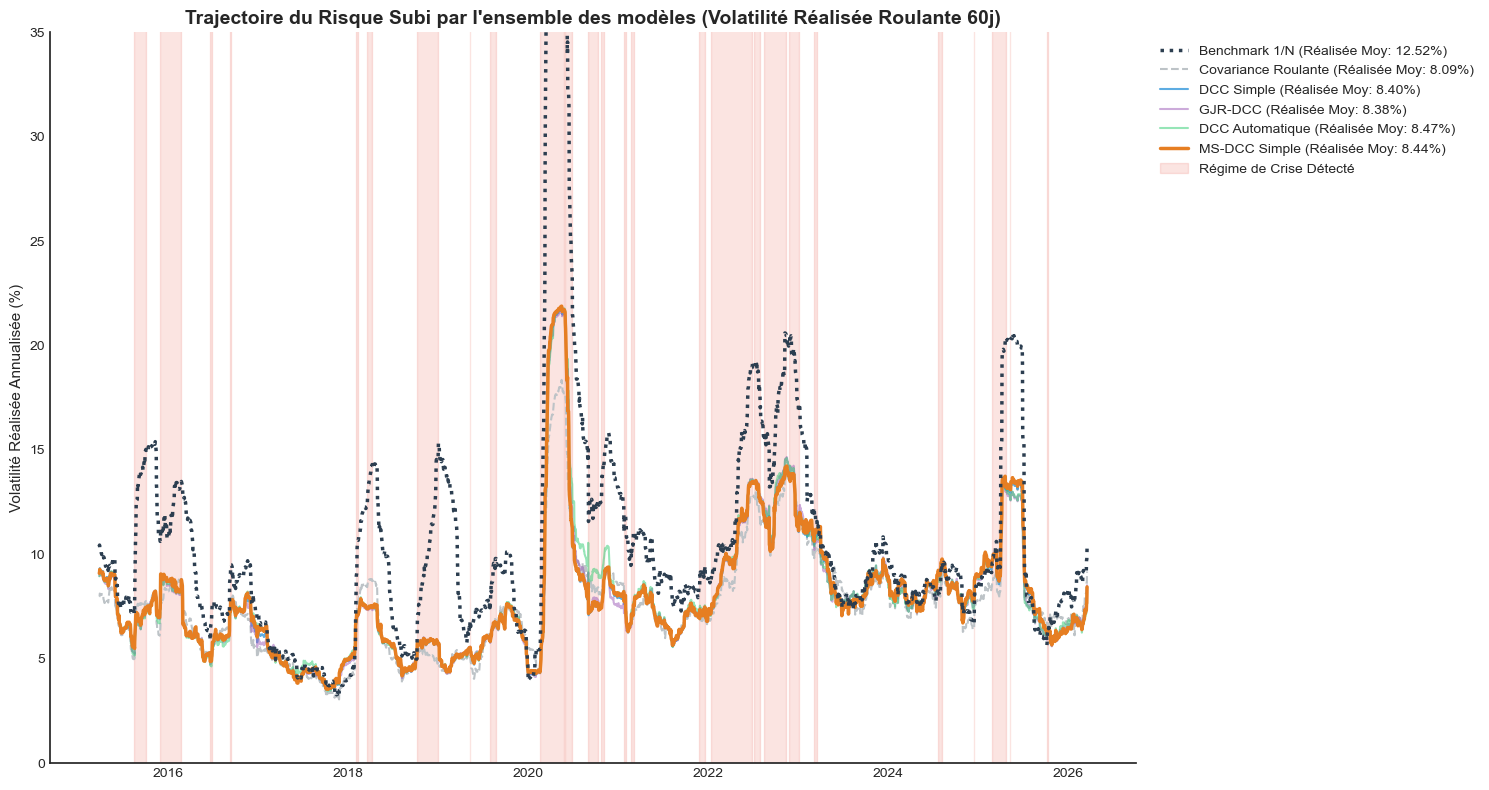

#### Classement Global : Réduction de la Volatilité Financière

Modèle,Volatilité Réalisée (%)
Cov. Roulante,8.087504
GJR-DCC,8.381335
DCC Simple,8.404339
MS-DCC Simple,8.439338
DCC Auto,8.473617
Benchmark 1/N,12.522265


#### Classement Global : Précision Économétrique (Minimisation QLIKE)

*Note : Le Benchmark 1/N ne prédisant pas de matrice conditionnelle, le QLIKE n'est pas applicable pour ce portefeuille naïf.*

Modèle,Fonction Perte (QLIKE)
DCC Simple,-0.443578
GJR-DCC,-0.439073
MS-DCC Simple,-0.431523
Cov. Roulante,-0.422307
DCC Auto,-0.417796


#### Matrice Diebold-Mariano (Significativité des écarts de perte)

*Note : Une valeur < 0.05 indique que le modèle en ligne bat formellement le modèle en colonne.*

,Cov. Roulante,DCC Simple,GJR-DCC,DCC Auto,MS-DCC Simple
Cov. Roulante,-,0.7518,0.6890,0.4484,0.6139
DCC Simple,0.2482,-,0.3534,0.0374,0.0000
GJR-DCC,0.3110,0.6466,-,0.0151,0.2749
DCC Auto,0.5516,0.9626,0.9849,-,0.8189
MS-DCC Simple,0.3861,1.0000,0.7251,0.1811,-


In [62]:
ann_f = np.sqrt(252)
window_days = 60 

# Calcul de la volatilité réalisée roulante pour l'INTÉGRALITÉ des modèles
roll_realized_vol = perf[[f"r_{m}" for m in ["stat", "sim", "gjr", "hyb", "ms", "eq"]]].rolling(window=window_days).std() * ann_f

fig, ax = plt.subplots(figsize=(15, 8))

# Traçage de toutes les courbes
ax.plot(roll_realized_vol.index, roll_realized_vol["r_eq"], label=f"Benchmark 1/N (Réalisée Moy: {perf['r_eq'].std()*ann_f:.2f}%)", color="#2c3e50", ls=":", lw=2.5, zorder=6)
ax.plot(roll_realized_vol.index, roll_realized_vol["r_stat"], label=f"Covariance Roulante (Réalisée Moy: {perf['r_stat'].std()*ann_f:.2f}%)", color="#bdc3c7", ls="--", zorder=2)
ax.plot(roll_realized_vol.index, roll_realized_vol["r_sim"], label=f"DCC Simple (Réalisée Moy: {perf['r_sim'].std()*ann_f:.2f}%)", color="#3498db", alpha=0.8, zorder=3)
ax.plot(roll_realized_vol.index, roll_realized_vol["r_gjr"], label=f"GJR-DCC (Réalisée Moy: {perf['r_gjr'].std()*ann_f:.2f}%)", color="#9b59b6", alpha=0.5, zorder=3)
ax.plot(roll_realized_vol.index, roll_realized_vol["r_hyb"], label=f"DCC Automatique (Réalisée Moy: {perf['r_hyb'].std()*ann_f:.2f}%)", color="#2ecc71", alpha=0.5, zorder=3)
ax.plot(roll_realized_vol.index, roll_realized_vol["r_ms"], label=f"MS-DCC Simple (Réalisée Moy: {perf['r_ms'].std()*ann_f:.2f}%)", color="#e67e22", lw=2.5, zorder=5)

ax.fill_between(perf.index, 0, 40, where=(ms_probs.loc[perf.index] > 0.5), color="#e74c3c", alpha=0.15, label="Régime de Crise Détecté", zorder=1)

ax.set_title(f"Trajectoire du Risque Subi par l'ensemble des modèles (Volatilité Réalisée Roulante {window_days}j)", fontweight="bold")
ax.set_ylabel("Volatilité Réalisée Annualisée (%)")
ax.set_ylim(0, 35)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

model_labels = ['Cov. Roulante', 'DCC Simple', 'GJR-DCC', 'DCC Auto', 'MS-DCC Simple', 'Benchmark 1/N']
models = ["stat", "sim", "gjr", "hyb", "ms", "eq"]

recap_data = []
for m, lbl in zip(models, model_labels):
    vol_real = perf[f'r_{m}'].std() * ann_f
    qlike = perf[f'qlike_{m}'].mean() if f'qlike_{m}' in perf.columns else np.nan
    recap_data.append({'Modèle': lbl, 'Volatilité Réalisée (%)': vol_real, 'Fonction Perte (QLIKE)': qlike})
    
df_rank = pd.DataFrame(recap_data)

display(Markdown("#### Classement Global : Réduction de la Volatilité Financière"))
display(df_rank[['Modèle', 'Volatilité Réalisée (%)']].sort_values(by='Volatilité Réalisée (%)', ascending=True).style.hide(axis="index"))

display(Markdown("#### Classement Global : Précision Économétrique (Minimisation QLIKE)"))
display(Markdown("*Note : Le Benchmark 1/N ne prédisant pas de matrice conditionnelle, le QLIKE n'est pas applicable pour ce portefeuille naïf.*"))
display(df_rank[['Modèle', 'Fonction Perte (QLIKE)']].dropna().sort_values(by='Fonction Perte (QLIKE)', ascending=True).style.hide(axis="index"))

dm_labels = model_labels[:-1]
dm_models = models[:-1]
dm_matrix = pd.DataFrame(index=dm_labels, columns=dm_labels)
for i, m_i in enumerate(dm_models):
    for j, m_j in enumerate(dm_models):
        if i == j: dm_matrix.iloc[i, j] = "-"
        else: dm_matrix.iloc[i, j] = f"{ttest_1samp(perf[f'qlike_{m_j}'] - perf[f'qlike_{m_i}'], 0, alternative='greater').pvalue:.4f}"

display(Markdown("#### Matrice Diebold-Mariano (Significativité des écarts de perte)"))
display(Markdown("*Note : Une valeur < 0.05 indique que le modèle en ligne bat formellement le modèle en colonne.*"))
display(dm_matrix)


## 7. Stress Tests : L'avantage markovien en période de crise (COVID-19 & Ukraine)

Le graphique affiche la volatilité réalisée roulante sur une fenêtre courte (22 jours, soit un mois boursier) pour capturer la dynamique des chocs violents et comparer la résilience de toutes les stratégies en concurrence.

* **Conclusion Analytique :** Lors du choc systémique prolongé de 2022 (guerre en Ukraine et inflation), le modèle MS-DCC Simple identifie le changement structurel et surpasse tous les autres modèles. Il amortit la crise bien plus efficacement que le portefeuille 1/N (qui explose littéralement) et les autres variantes dynamiques, démontrant la puissance protectrice d'une allocation par filtre de Markov en régime de stress absolu.


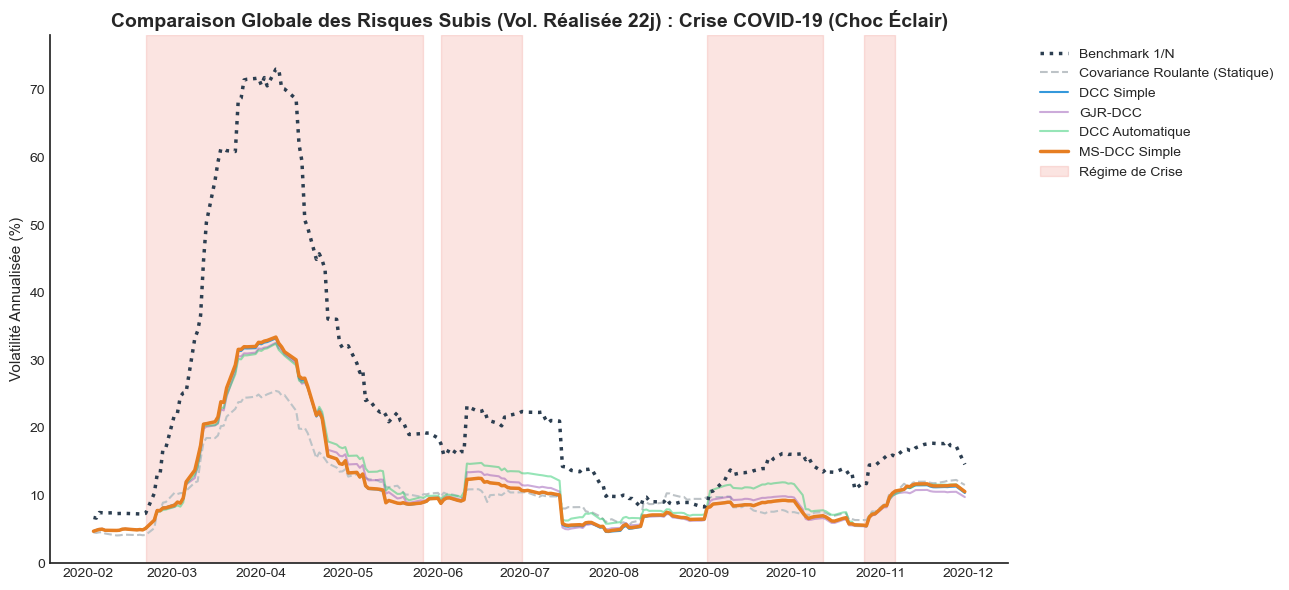

#### Résultats détaillés : Crise COVID-19 (Choc Éclair)

**1. Meilleur Bouclier Financier (Réduction de la Volatilité) :**

Modèle,Volatilité Réalisée (%)
Cov. Roulante,12.226384
DCC Simple,13.570119
GJR-DCC,13.599645
MS-DCC Simple,13.661030
DCC Auto,14.152686
Benchmark 1/N,28.793595


**2. Meilleure Précision Économétrique (Score QLIKE) :**

Modèle,QLIKE (Précision)
DCC Simple,0.448373
MS-DCC Simple,0.474117
GJR-DCC,0.498847
DCC Auto,0.711852
Cov. Roulante,0.883431


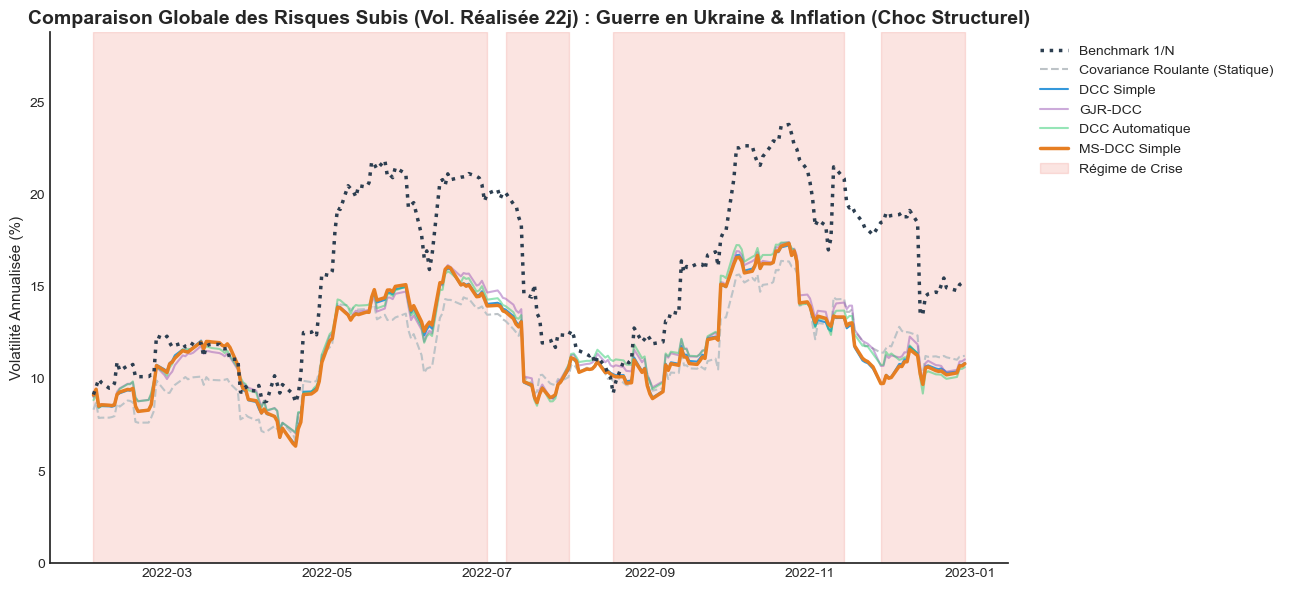

#### Résultats détaillés : Guerre en Ukraine & Inflation (Choc Structurel)

**1. Meilleur Bouclier Financier (Réduction de la Volatilité) :**

Modèle,Volatilité Réalisée (%)
Cov. Roulante,11.623388
MS-DCC Simple,12.042277
DCC Simple,12.048609
DCC Auto,12.239455
GJR-DCC,12.264408
Benchmark 1/N,16.415046


**2. Meilleure Précision Économétrique (Score QLIKE) :**

Modèle,QLIKE (Précision)
MS-DCC Simple,0.535882
Cov. Roulante,0.538463
DCC Simple,0.543675
GJR-DCC,0.628396
DCC Auto,0.631343


In [65]:
crises = {
    "Crise COVID-19 (Choc Éclair)": ("2020-02-01", "2020-11-30"),
    "Guerre en Ukraine & Inflation (Choc Structurel)": ("2022-02-01", "2022-12-31")
}

window_stress = 22 # Fenêtre courte (1 mois boursier)
# Extraction intégrale
roll_realized_stress = perf[[f"r_{m}" for m in ["stat", "sim", "gjr", "hyb", "ms", "eq"]]].rolling(window=window_stress).std() * ann_f

for nom_crise, (start_date, end_date) in crises.items():
    mask_perf = (perf.index >= start_date) & (perf.index <= end_date)
    perf_crise = perf.loc[mask_perf]
    if perf_crise.empty: continue
        
    roll_crise = roll_realized_stress.loc[mask_perf]

    fig, ax = plt.subplots(figsize=(13, 6))
    
    ax.plot(roll_crise.index, roll_crise["r_eq"], label="Benchmark 1/N", color="#2c3e50", ls=":", lw=2.5, zorder=6)
    ax.plot(roll_crise.index, roll_crise["r_stat"], label="Covariance Roulante (Statique)", color="#bdc3c7", ls="--", zorder=2)
    ax.plot(roll_crise.index, roll_crise["r_sim"], label="DCC Simple", color="#3498db", zorder=3)
    ax.plot(roll_crise.index, roll_crise["r_gjr"], label="GJR-DCC", color="#9b59b6", alpha=0.5, zorder=3)
    ax.plot(roll_crise.index, roll_crise["r_hyb"], label="DCC Automatique", color="#2ecc71", alpha=0.5, zorder=3)
    ax.plot(roll_crise.index, roll_crise["r_ms"], label="MS-DCC Simple", color="#e67e22", lw=2.5, zorder=5)

    probs_crise = ms_probs.loc[perf_crise.index]
    y_max = roll_crise.max().max() + 5
    if pd.isna(y_max): y_max = 40
    
    ax.fill_between(perf_crise.index, 0, y_max, where=(probs_crise > 0.5), color="#e74c3c", alpha=0.15, label="Régime de Crise", zorder=1)
    
    ax.set_title(f"Comparaison Globale des Risques Subis (Vol. Réalisée {window_stress}j) : {nom_crise}", fontweight="bold")
    ax.set_ylabel("Volatilité Annualisée (%)")
    ax.set_ylim(0, y_max)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
    plt.tight_layout()
    plt.show()

    recap_crise = []
    for m, lbl in zip(models, model_labels):
        vol_real = perf_crise[f'r_{m}'].std() * ann_f
        qlike = perf_crise[f'qlike_{m}'].mean() if f'qlike_{m}' in perf_crise.columns else np.nan
        recap_crise.append({'Modèle': lbl, 'Volatilité Réalisée (%)': vol_real, 'QLIKE (Précision)': qlike})
        
    df_crise_rank = pd.DataFrame(recap_crise)
    
    display(Markdown(f"#### Résultats détaillés : {nom_crise}"))
    
    display(Markdown("**1. Meilleur Bouclier Financier (Réduction de la Volatilité) :**"))
    display(df_crise_rank[['Modèle', 'Volatilité Réalisée (%)']].sort_values(by='Volatilité Réalisée (%)', ascending=True).style.hide(axis="index"))

    display(Markdown("**2. Meilleure Précision Économétrique (Score QLIKE) :**"))
    display(df_crise_rank[['Modèle', 'QLIKE (Précision)']].dropna().sort_values(by='QLIKE (Précision)', ascending=True).style.hide(axis="index"))


## Annexe Mathématique : Processus Itératifs des Matrices Conditionnelles (Valeurs Estimées)

Les équations ci-dessous décrivent la mécanique exacte de mise à jour des matrices de pseudo-corrélation $Q_t$. Elles intègrent les paramètres d'innovation ($\alpha$) et de persistance ($\beta$) **réellement estimés par maximum de vraisemblance**.


In [67]:
from IPython.display import Math

display(Markdown("#### 1. Modèle DCC Simple (Marges Symétriques) :"))
eq_sim = r"Q_{s,t} = " + f"{(1 - a_sim - b_sim):.4f}" + r" \bar{Q}_s + " + f"{a_sim:.4f}" + r" \left( z_{s,t-1} z_{s,t-1}^T \right) + " + f"{b_sim:.4f}" + r" Q_{s,t-1}"
display(Math(eq_sim))

display(Markdown("#### 2. Modèle GJR-DCC (Marges Asymétriques unifiées) :"))
eq_gjr = r"Q_{g,t} = " + f"{(1 - a_gjr - b_gjr):.4f}" + r" \bar{Q}_g + " + f"{a_gjr:.4f}" + r" \left( z_{g,t-1} z_{g,t-1}^T \right) + " + f"{b_gjr:.4f}" + r" Q_{g,t-1}"
display(Math(eq_gjr))

display(Markdown("#### 3. Modèle DCC Automatique (Marges Spécifiques minimisant l'AIC) :"))
eq_hyb = r"Q_{h,t} = " + f"{(1 - a_hyb - b_hyb):.4f}" + r" \bar{Q}_h + " + f"{a_hyb:.4f}" + r" \left( z_{h,t-1} z_{h,t-1}^T \right) + " + f"{b_hyb:.4f}" + r" Q_{h,t-1}"
display(Math(eq_hyb))

display(Markdown("#### 4. Modèle MS-DCC Simple (Filtre de Markov sur Marges Robustes) :"))
display(Markdown("La pondération s'adapte dynamiquement selon la probabilité de crise $p_t$ détectée sur le S&P 500 :"))

eq_alpha_m = r"\alpha_{m,t} = " + f"{a0_mle:.4f}" + r" \cdot (1 - p_t) + " + f"{a1_mle:.4f}" + r" \cdot p_t"
eq_beta_m = r"\beta_{m,t} = " + f"{b0_mle:.4f}" + r" \cdot (1 - p_t) + " + f"{b1_mle:.4f}" + r" \cdot p_t"
eq_qm = r"Q_{m,t} = (1 - \alpha_{m,t} - \beta_{m,t}) \bar{Q}_s + \alpha_{m,t} \left( z_{s,t-1} z_{s,t-1}^T \right) + \beta_{m,t} Q_{m,t-1}"

display(Math(eq_alpha_m))
display(Math(eq_beta_m))
display(Math(eq_qm))

display(Markdown("#### 5. Projection vers la Matrice de Covariance et Poids GMV :"))
eq_r = r"R_t = \text{diag}(Q_t)^{-1/2} Q_t \text{diag}(Q_t)^{-1/2}"
eq_sigma = r"\Sigma_t = D_t R_t D_t \quad \text{avec} \quad D_t = \text{diag}\left(\sqrt{h_{i,t}}\right)"
eq_gmv = r"w_t = \frac{\Sigma_t^{-1} \mathbf{1}}{\mathbf{1}^T \Sigma_t^{-1} \mathbf{1}}"

display(Math(eq_r))
display(Math(eq_sigma))
display(Math(eq_gmv))


#### 1. Modèle DCC Simple (Marges Symétriques) :

<IPython.core.display.Math object>

#### 2. Modèle GJR-DCC (Marges Asymétriques unifiées) :

<IPython.core.display.Math object>

#### 3. Modèle DCC Automatique (Marges Spécifiques minimisant l'AIC) :

...

<IPython.core.display.Math object>

#### 5. Projection vers la Matrice de Covariance et Poids GMV :

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>